# Машинное обучение, ФКН ВШЭ

## Практическое задание 5. Решающие деревья

### Общая информация
Дата выдачи: 29.11.2024

Мягий дедлайн: 23:59 11.12.2024

Жестокий дедлайн: 23:59 13.12.2024

### О задании

Задание состоит из трёх разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево для классификации и сравните его со стандартное имплементацией из sklearn.
3. В третьем разделе вы сделаете решающее дерево для регрессии, в листьях которого линейные модели.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 12.5 баллов.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.


### Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-05-trees-Username.ipynb
* Модуль hw5code.py
* Ссылки на посылки в Яндекс.Контесте для обеих задач

В контест [https://contest.yandex.ru/contest/72492] нужно отправить файл hw5code.py с реализованными функциями и классами.

Username — ваша фамилия и имя на латинице именно в таком порядке

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже:

__Оценка:__

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим три простых двумерных датасета сделанных с помощью `make_moons`, `make_circles`, `make_classification` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [2]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, )
]

In [3]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

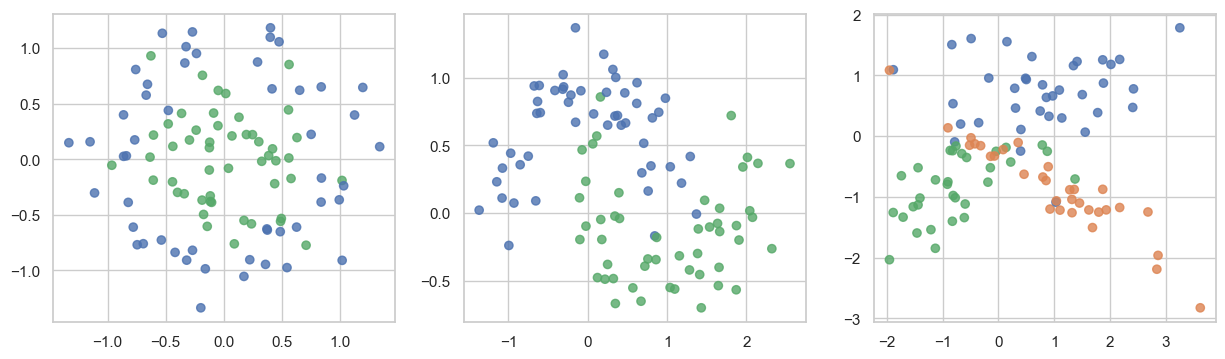

In [4]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [5]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

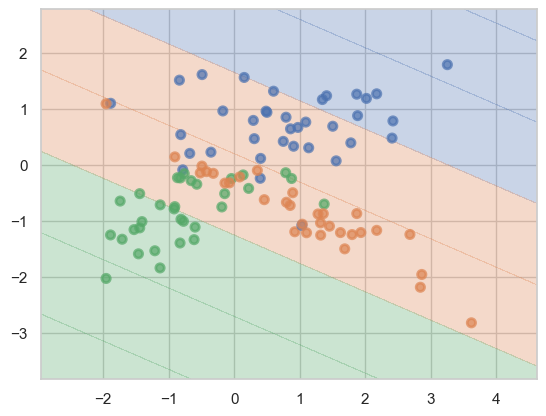

In [6]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

Score train & test 1: (1.0, 0.76)
Score train & test 2: (1.0, 0.88)
Score train & test 3: (1.0, 0.88)


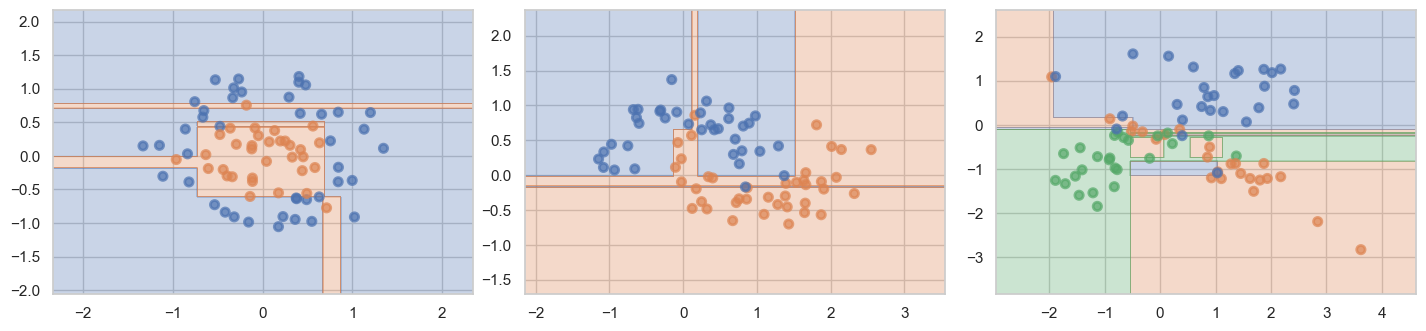

In [19]:
from sklearn.metrics import accuracy_score

plt.figure(figsize=(15, 4))
for i, (X, y) in enumerate(datasets):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
    dec_tree = DecisionTreeClassifier(random_state=42)
    dec_tree.fit(X_train, y_train)
    
    plt.subplot(1, 3, i + 1)
    plot_surface(dec_tree, X_train, y_train)
    
    print(f'Score train & test {i + 1}: {accuracy_score(dec_tree.predict(X_train), y_train), accuracy_score(dec_tree.predict(X_test), y_test)}')

__Ответ:__ Переобучилась, так как accuracy testа на много ниже train и в train везде 1.

__Задание 2. (1.25 баллов)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки / accuracy. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

__Бонус (0.75 баллов)__

Вместо того, чтобы рисовать  кучу графиков, сделайте интерактивную визуализацию разделяющей гиперплоскости с помощью библиотеки `plotly` (конкретнее, вам пригодится `plotly.graph_objects`): у вас должен получиться виджет с ползунком, по которому можно выбрать параметры `max_depth` и `min_samples_leaf` и посмотреть, как в зависимости от них меняется разделяющая поверхность и прогнозы модели. Если всё сделать аккуратно, получится очень красиво. Помните, что при загрузке в anytask виджеты могут много весить и надо подождать. Если ваш ноутбук не загружается -- попробуйте загрузить сначала с очищенным выводом этой ячейки. 

Заранее предупреждаем, что бонус сложный. Полезно будет ознакомиться:
 - https://plotly.com/python/sliders/
 - https://plotly.com/python/dropdowns/
 - https://plotly.com/python/knn-classification/

In [36]:
import plotly.graph_objects as go
import seaborn as sns

max_depth_values = [1, 2, 3, 4, 5]
min_samples_leaf_values = [1, 2, 3, 4, 5]

fig = go.Figure()

for dataset_index, (X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)

    hex_palette = ['#%02x%02x%02x' % (int(r*255), int(g*255), int(b*255)) for r, g, b in palette]

    for max_depth in max_depth_values:
        for min_samples_leaf in min_samples_leaf_values:
            dec_tree = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=42)
            dec_tree.fit(X_train, y_train)
            
            train_accuracy = accuracy_score(y_train, dec_tree.predict(X_train))
            test_accuracy = accuracy_score(y_test, dec_tree.predict(X_test))
            #print(dataset_index, max_depth, min_samples_leaf, train_accuracy, test_accuracy)
            x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
            y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
            xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                                 np.arange(y_min, y_max, 0.1))
            Z = dec_tree.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)
            
            fig.add_trace(go.Contour(x=np.arange(x_min, x_max, 0.1),
                                     y=np.arange(y_min, y_max, 0.1),
                                     z=Z,
                                     showscale=False,
                                     colorscale=hex_palette,
                                     opacity=0.3,
                                     name=f"Dataset {dataset_index + 1}, max_depth={max_depth}, min_samples_leaf={min_samples_leaf}, Train Acc={train_accuracy:.2f}, Test Acc={test_accuracy:.2f}",
                                     visible=False))
            
            fig.add_trace(go.Scatter(x=X[:, 0], y=X[:, 1],
                                     mode='markers',
                                     marker=dict(color=y, colorscale=hex_palette, line=dict(width=2, color='black')),
                                     name=f"Data Points",
                                     visible=False))

for i in range(0, len(fig.data), 2 * len(max_depth_values) * len(min_samples_leaf_values)):
    fig.data[i].visible = True
    fig.data[i + 1].visible = True

steps = []
for i in range(0, len(fig.data), 2):
    step = dict(
        method="update",
        args=[{"visible": [False] * len(fig.data)},
              {"title": fig.data[i].name}],
    )
    step["args"][0]["visible"][i] = True
    step["args"][0]["visible"][i + 1] = True
    steps.append(step)

sliders = [dict(
    active=0,
    currentvalue={"prefix": "Parameters: "},
    pad={"t": 50},
    steps=steps
)]

fig.update_layout(
    sliders=sliders
)

fig.show()

__Ответ:__ Регуляризация улучшает обобщающую способность модели, предотвращая переобучение, особенно на сложных датасетах, где модель склонна подстраиваться под обучающие данные. На простых датасетах эффект может быть менее заметен, так как изначально качество модели уже высокое.

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw5code.py

https://contest.yandex.ru/contest/72492/run-report/129390680/

__Задание 4. (0.5 балла)__

Загрузите таблицу [students.csv](https://github.com/esokolov/ml-course-hse/blob/master/2022-fall/homeworks-practice/homework-practice-05-trees/students.csv) (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

In [47]:
df = pd.read_csv('students.csv')
df.head()

,STG,SCG,STR,LPR,PEG,UNS
0,0.00,0.00,0.00,0.00,0.00,0
1,0.08,0.08,0.10,0.24,0.90,1
2,0.06,0.06,0.05,0.25,0.33,0
3,0.10,0.10,0.15,0.65,0.30,1
4,0.08,0.08,0.08,0.98,0.24,0


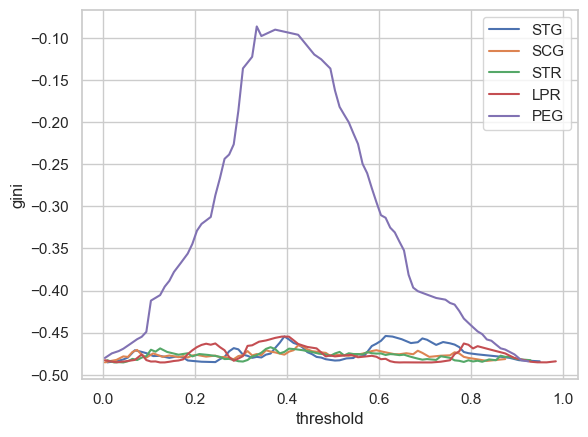

In [54]:
for name in df.columns[:-1]:
    thresholds, ginis, _, _ = find_best_split(df[name], df['UNS'])
    plt.plot(thresholds, ginis, label=name)
plt.ylabel('gini')
plt.xlabel('threshold')
plt.legend()
plt.show()

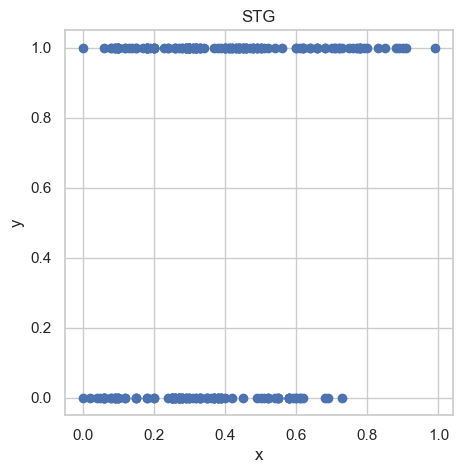

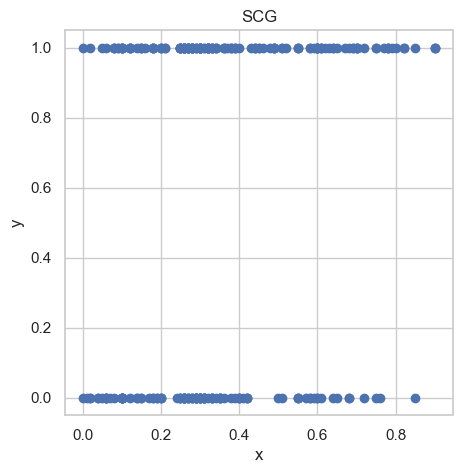

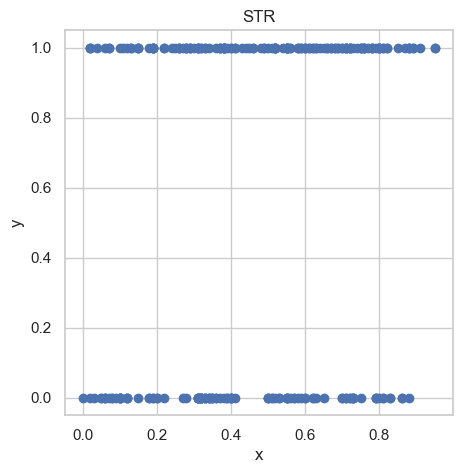

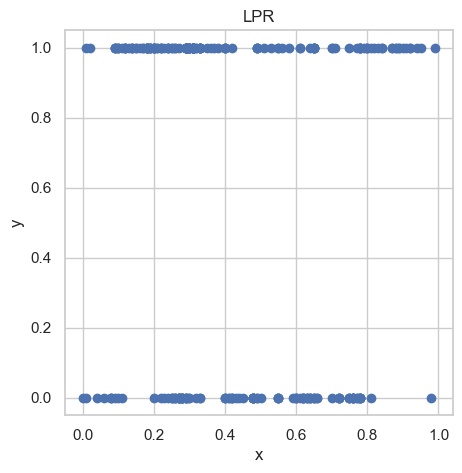

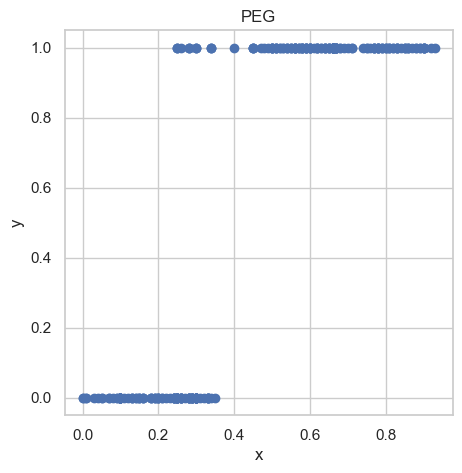

In [59]:
for name in df.columns[:-1]:
    plt.figure(figsize=(5,5))
    plt.scatter(df[name], df['UNS'])
    plt.title(name)
    plt.ylabel('y')
    plt.xlabel('x')
    plt.show()

__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:** Деление должен быть по признаку PEG, так как у него хорошо отделены границы. Хорошие признаки - например, в данных есть идеальная точка, где ниже и больше его разделяются на разные классы, а если по кривой - то должна выглядеть как "гора", а неудобные признаки - все точки(кривой) равномерно везде.

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw5code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в [лекции](https://github.com/esokolov/ml-course-hse/blob/master/2020-fall/lecture-notes/lecture07-trees.pdf) в разделе «Построение дерева». Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

https://contest.yandex.ru/contest/72492/run-report/129419365/

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [62]:
df = pd.read_csv('agaricus-lepiota.data')
df.head()

,p,x,s,n,t,p.1,f,c,n.1,k,...,s.2,w,w.1,p.2,w.2,o,p.3,k.1,s.3,u
0,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
1,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
2,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
3,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
4,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g


In [68]:
from sklearn.preprocessing import LabelEncoder
from hw5code import DecisionTree

for col in df.columns:
    label_enc = LabelEncoder()
    df[col] = label_enc.fit_transform(df[col])


X = df.drop('p', axis=1)
y = df['p']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

tree = DecisionTree(['real'] * df.shape[1])
tree.fit(X_train.values, y_train.values)
y_pred = tree.predict(X_test.values)

print(f'Accuracy: {accuracy_score(y_pred, y_test.values)}')

Accuracy: 1.0


__Задание 8. (1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (https://github.com/esokolov/ml-course-hse/blob/master/2024-fall/homework-practice/homework-practice-05-trees/tic-tac-toe-endgame.csv).

In [2]:
df = pd.read_csv('tic-tac-toe-endgame.csv')
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
0,x,x,x,x,o,o,x,o,o,positive
1,x,x,x,x,o,o,o,x,o,positive
2,x,x,x,x,o,o,o,o,x,positive
3,x,x,x,x,o,o,o,b,b,positive
4,x,x,x,x,o,o,b,o,b,positive


In [3]:
from sklearn.preprocessing import LabelEncoder
from hw5code import DecisionTree

for col in df.columns:
    label_enc = LabelEncoder()
    df[col] = label_enc.fit_transform(df[col])


X = df.drop('V10', axis=1)
y = df['V10']
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, test_size=0.5, random_state=42)

tree = DecisionTree(['categorical'] * X_train.shape[1])
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

print(f'Accuracy: {accuracy_score(y_pred, y_test)}')

Accuracy: 0.9478079331941545


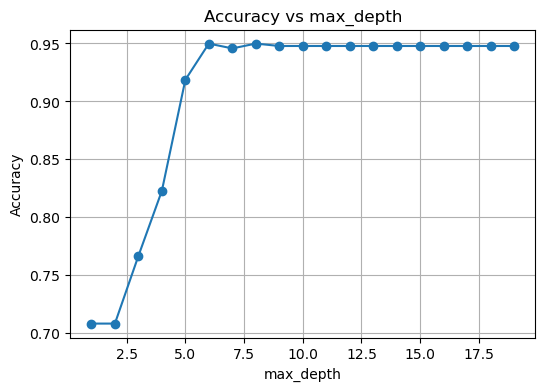

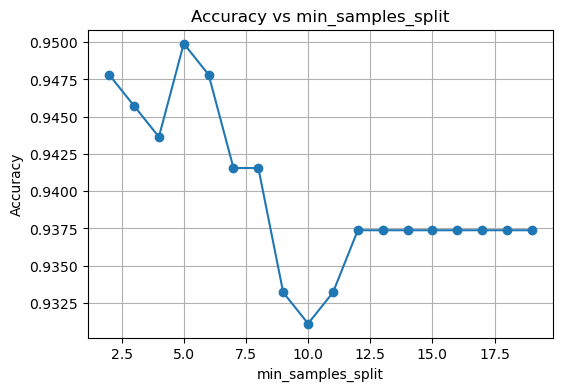

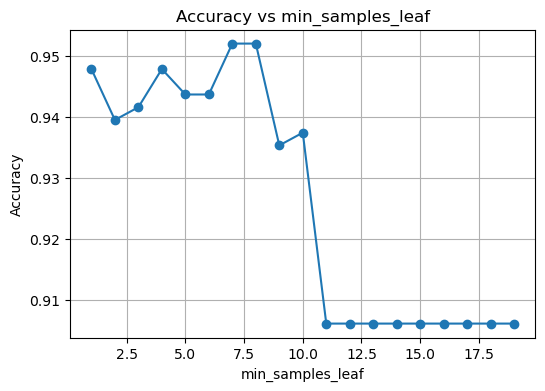

In [4]:
from hw5code import DecisionTree
import numpy as np
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

def plot_accuracy_vs_param(param_name, param_values):
    accuracies = []
    for value in param_values:
        if param_name == "max_depth":
            clf = DecisionTree(['categorical'] * X_train.shape[1], max_depth=value)
            #print(1)
        elif param_name == "min_samples_split":
            clf = DecisionTree(['categorical'] * X_train.shape[1], min_samples_split=value)
        elif param_name == "min_samples_leaf":
            clf = DecisionTree(['categorical'] * X_train.shape[1], min_samples_leaf=value)
            
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
    
    plt.figure(figsize=(6, 4))
    plt.plot(param_values, accuracies, marker='o')
    plt.title(f'Accuracy vs {param_name}')
    plt.xlabel(param_name)
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.show()

plot_accuracy_vs_param('max_depth', range(1, 20))
plot_accuracy_vs_param('min_samples_split', range(2, 20))
plot_accuracy_vs_param('min_samples_leaf', range(1, 20))

__Задание 9. (до 3-х баллов)__

Реализуйте класс `LinearRegressionTree`:

 - Если вам удобно, можете сделать его наследуемым от `DecisionTree` и переопределить только необходимые методы. Можете добавить новые — как вам нравится.
 - В листьях находятся не константные предсказания, а линейные модели (можно использовать из библиотеки `sklearn`).
 - Ваша реализация должна решать задачу __регрессии__, поэтому для поиска оптимального разбиения нужно написать новую функцию.
 - **Максимум 1.8 балла, если**:
   - В качестве критерия для разбиения считаете среднее квадратное/абсолютное отклонение
   - Перебираете все пороги
   - Ваша реализация строится как обычное решающее дерево для регрессии, но в листьях линейные модели.
   - Есть поддержка параметра max_depth
 - **Максимум три балла, если выполнено следующее**:
     - Для разбиения перебираются не все пороги. Пороги выбираются из значений признаков, разбитых на квантили.
     - Для разбиении выбирается порог, который минимизирует суммарную ошибку линейных моделей после разбиения: $$\text{loss} = \frac{n_{left}}{n} \cdot \text{loss}_{left} + \frac{n_{right}}{n} \cdot \text{loss}_{right}$$ (Разумеется, для оценки этих ошибок вам надо будет строить много линейных моделей, это не дисперсии. В качестве функционала ошибки возьмите MAE или MSE)
     - Есть поддержка параметров max_depth, min_samples_split, min_samples_leaf

In [28]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.base import BaseEstimator

class LinearRegressionTree(BaseEstimator):
    def __init__(self, feature_types, base_model_type=LinearRegression, max_depth=None, min_samples_split=2, min_samples_leaf=1, quantile_step=0.1):
        self.feature_types = feature_types
        self.base_model_type = base_model_type
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.quantile_step = quantile_step
        self.tree_ = None

    def fit(self, X, y):
        self.tree_ = self._build_tree(X, y)
        return self

    def _build_tree(self, X, y, depth=0):
        if len(y) < self.min_samples_split or (self.max_depth is not None and depth >= self.max_depth):
            return {'model': self.base_model_type().fit(X, y)}

        best_feature, best_threshold, best_loss = None, None, float('inf')
        for feature in range(X.shape[1]):
            if self.feature_types[feature] != "real":
                continue

            thresholds = np.quantile(X[:, feature], np.arange(0, 1, self.quantile_step))
            for threshold in thresholds:
                left_indices = X[:, feature] < threshold
                right_indices = ~left_indices

                if sum(left_indices) < self.min_samples_leaf or sum(right_indices) < self.min_samples_leaf:
                    continue

                left_model = self.base_model_type().fit(X[left_indices], y[left_indices])
                right_model = self.base_model_type().fit(X[right_indices], y[right_indices])

                left_loss = mean_squared_error(y[left_indices], left_model.predict(X[left_indices]))
                right_loss = mean_squared_error(y[right_indices], right_model.predict(X[right_indices]))

                loss = (sum(left_indices) * left_loss + sum(right_indices) * right_loss) / len(y)

                if loss < best_loss:
                    best_feature, best_threshold, best_loss = feature, threshold, loss

        if best_feature is None:
            return {'model': self.base_model_type().fit(X, y)}

        left_indices = X[:, best_feature] < best_threshold
        right_indices = ~left_indices

        return {
            'feature': best_feature,
            'threshold': best_threshold,
            'left': self._build_tree(X[left_indices], y[left_indices], depth + 1),
            'right': self._build_tree(X[right_indices], y[right_indices], depth + 1)
        }

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree_) for x in X])

    def _predict_one(self, x, tree):
        if 'model' in tree:
            return tree['model'].predict([x])[0]
        if x[tree['feature']] < tree['threshold']:
            return self._predict_one(x, tree['left'])
        else:
            return self._predict_one(x, tree['right'])


__Задание 10. (1 балл)__

Проведите эксперименты с реализованным вами линейным деревом на любом подходящем датасете из sklearn (https://scikit-learn.org/1.5/datasets/real_world.html), который вам нравится. Подберите лучшие гиперпараметры (max_depth и остальные, если вы их реализовывали). Сравните ваше дерево со стандартным деревом для регрессии из sklearn, для него тоже подберите гиперпараметры.

In [38]:
from sklearn.datasets import fetch_olivetti_faces
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


data = fetch_olivetti_faces()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)


In [30]:
pd.DataFrame(data.data).head()

,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.665289,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.136364,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.074380,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.652893,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.190083,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554


In [27]:
clf = LinearRegressionTree(['real'] * X_train.shape[1], max_depth=5)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [37]:
from sklearn.metrics import mean_squared_error

for max_depth in [1, 2, 3, 4, 5]:
    clf = LinearRegressionTree(['real'] * X_train.shape[1], max_depth=max_depth)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f'Max_depth: {max_depth}, Accuracy: {mean_squared_error(y_test, y_pred)}')

Max_depth: 1, Accuracy: 80.3822865407038
Max_depth: 2, Accuracy: 73.58501450159021
Max_depth: 3, Accuracy: 81.46297372379438
Max_depth: 4, Accuracy: 107.4730361893707
Max_depth: 5, Accuracy: 121.16475346178947


In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from tqdm import tqdm 

dict_ = {}

for max_depth in tqdm(range(1, 500), desc="Max Depth"):
    dec_tree = DecisionTreeClassifier(max_depth=max_depth)
    dec_tree.fit(X_train, y_train)
    y_pred = dec_tree.predict(X_test)
    dict_[accuracy_score(y_test, y_pred)] = max_depth
        
print(f'Max_depth: {dict_[max(dict_.keys())]}, Accuracy: {max(dict_.keys())}')


Max Depth: 100%|█████████████████████████████████████████| 499/499 [06:41<00:00,  1.24it/s]

Max_depth: 471, Accuracy: 0.415


In [51]:
best_lintree_depth = 2
best_dectree_depth = dict_[max(dict_.keys())]


Посмотрите, что будет, если обучить ваше дерево на данных, которые сгенерированы внизу. Нарисуйте график с предсказаниями и таргетами на всей выборке, сравните с обычным деревом.

Напишите, какие достоинства и недостатки вы видите у реализованного вами линейного дерева.

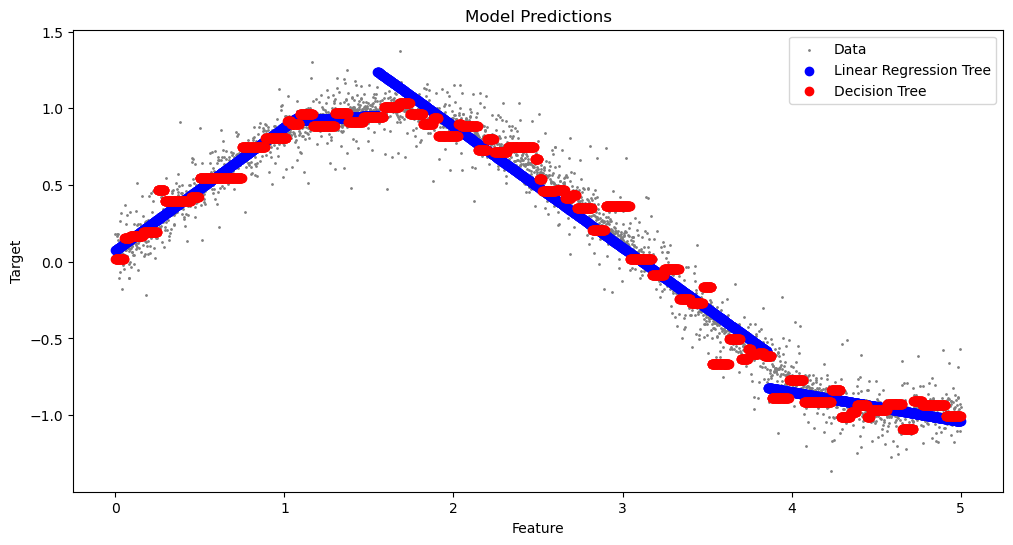

In [54]:
n_samples = 3_000
x = np.linspace(0, 5, n_samples).reshape(-1, 1)
y = np.sin(x.flatten()) + np.random.normal(0, 0.1, n_samples) * np.random.normal(0, 1, n_samples)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.95, random_state=0x4b524f4c2d562d53544f594c4f % (2 ** 32 - 1))



linear_tree = LinearRegressionTree(['real'] * x_train.shape[1], max_depth=best_lintree_depth)
linear_tree.fit(x_train, y_train)
y_pred_linear_tree = linear_tree.predict(x_test)

decision_tree = DecisionTreeRegressor(max_depth=best_dectree_depth, min_samples_leaf=best_dectree_leaf)
decision_tree.fit(x_train, y_train)
y_pred_decision_tree = decision_tree.predict(x_test)

plt.figure(figsize=(12, 6))
plt.scatter(x_test, y_test, color='gray', s=1, label='Data')
plt.scatter(x_test, y_pred_linear_tree, color='blue', label='Linear Regression Tree', linewidth=1)
plt.scatter(x_test, y_pred_decision_tree, color='red', label='Decision Tree', linewidth=1)
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Model Predictions')
plt.legend()
plt.show()

**Ответ:** Минус модели в том, что если данные не были "гладким прямым", т.е. имеет много волн, то будет плохо предсказывать, а так то все хорошо.

Вставьте что угодно, описывающее ваши впечатления от этого задания:

Categorical, categorical